In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend, butter, filtfilt

VIDEO_PATH = "../data/subject1/vid.avi"
ROI_PATH   = "../outputs/roi_coords.npy"
GT_PATH    = "../data/subject1/ground_truth.txt"

# Clip parameters
T       = 30       # frames per clip (~1 second at 29fps)
STRIDE  = 5        # step between clips
H, W    = 32, 32   # resize each frame to this

fps = 29.264106

roi_coords = np.load(ROI_PATH)
gt_data    = np.loadtxt(GT_PATH)
ppg_gt     = gt_data[0]

print(f"Total frames  : {len(roi_coords)}")
print(f"Clip length   : {T} frames  (~{T/fps:.1f}s)")
print(f"Stride        : {STRIDE} frames")
print(f"Expected clips: {(len(roi_coords) - T) // STRIDE}")

Total frames  : 1547
Clip length   : 30 frames  (~1.0s)
Stride        : 5 frames
Expected clips: 303


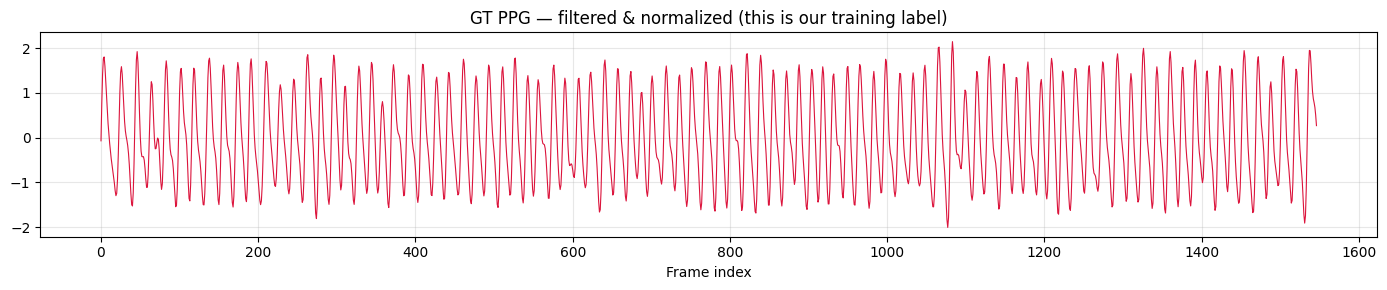

In [2]:
def bandpass_filter(signal, lowcut=0.7, highcut=4.0, fs=29.264106, order=4):
    nyq  = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

ppg_filtered = bandpass_filter(detrend(ppg_gt))
ppg_filtered = (ppg_filtered - ppg_filtered.mean()) / ppg_filtered.std()

plt.figure(figsize=(14, 3))
plt.plot(ppg_filtered, color='crimson', linewidth=0.8)
plt.title("GT PPG — filtered & normalized (this is our training label)")
plt.xlabel("Frame index"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Frames array shape : (1547, 32, 32, 3)
Pixel range        : 0.11 – 0.88


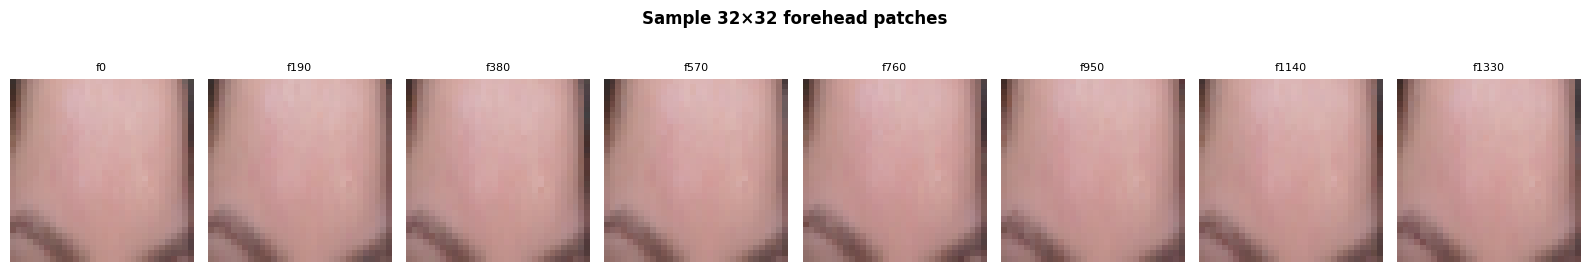

In [3]:
# Load every frame, crop ROI, resize to 32x32, normalize to [0,1]
cap    = cv2.VideoCapture(VIDEO_PATH)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frames = []

for i in range(n_frames):
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    x1, y1, x2, y2 = roi_coords[i]

    patch = frame_rgb[y1:y2, x1:x2]                  # crop forehead
    patch = cv2.resize(patch, (W, H))                 # resize to 32x32
    patch = patch.astype(np.float32) / 255.0          # normalize [0,1]
    frames.append(patch)

cap.release()
frames = np.array(frames)   # shape: (1547, 32, 32, 3)

print(f"Frames array shape : {frames.shape}")
print(f"Pixel range        : {frames.min():.2f} – {frames.max():.2f}")

# Visualize a few patches
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
fig.suptitle("Sample 32×32 forehead patches", fontweight='bold')
for i, ax in enumerate(axes):
    idx = i * 190
    ax.imshow(frames[idx])
    ax.set_title(f"f{idx}", fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()

In [4]:
clips    = []
labels   = []

for start in range(0, len(frames) - T, STRIDE):
    end      = start + T
    clip     = frames[start:end]           # (T, 32, 32, 3)
    label    = ppg_filtered[start:end]     # (T,)
    clips.append(clip)
    labels.append(label)

clips  = np.array(clips)    # (N, T, H, W, 3)
labels = np.array(labels)   # (N, T)

print(f"Dataset shape")
print(f"  clips  : {clips.shape}   — (N clips, T frames, H, W, channels)")
print(f"  labels : {labels.shape}  — (N clips, T signal values)")

Dataset shape
  clips  : (304, 30, 32, 32, 3)   — (N clips, T frames, H, W, channels)
  labels : (304, 30)  — (N clips, T signal values)


In [5]:
# 80% train, 20% val — split by time (not random, to avoid leakage)
split    = int(len(clips) * 0.8)

X_train, X_val = clips[:split],  clips[split:]
y_train, y_val = labels[:split], labels[split:]

print(f"Train : {X_train.shape[0]} clips")
print(f"Val   : {X_val.shape[0]}  clips")

np.save("../outputs/X_train.npy", X_train)
np.save("../outputs/X_val.npy",   X_val)
np.save("../outputs/y_train.npy", y_train)
np.save("../outputs/y_val.npy",   y_val)

print("\nSaved → outputs/X_train, X_val, y_train, y_val")

Train : 243 clips
Val   : 61  clips

Saved → outputs/X_train, X_val, y_train, y_val
